In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt

# ---- Paths to saved evaluation artifacts (from earlier notebooks) ----
# Update these if your folder names differ.
PATH_META_THRESH  = "../outputs/fakenewsnet_metadata/threshold_results.csv"
PATH_TEXT_THRESH  = "../outputs/fakenewsnet_text/threshold_results.csv"
PATH_HYB_THRESH   = "../outputs/fakenewsnet_hybrid/threshold_results.csv"

OUT_DIR = "../outputs/model_comparison"
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def load_thresh(path, model_name):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing threshold table: {path}")
    df = pd.read_csv(path)
    df["model"] = model_name
    return df

meta_df = load_thresh(PATH_META_THRESH, "Stage 3B Meta-only (PolitiFact)")
text_df = load_thresh(PATH_TEXT_THRESH, "Stage 3B Text-only (PolitiFact)")
hyb_df  = load_thresh(PATH_HYB_THRESH,  "Stage 3B Hybrid (PolitiFact)")

all_thresh = pd.concat([meta_df, text_df, hyb_df], ignore_index=True)
all_thresh.head()


,threshold,accuracy,precision,recall,f1,TP,FP,TN,FN,model
0,0.1,0.419811,0.414286,1.000000,0.585859,87,123,2,0,Stage 3B Meta-only (PolitiFact)
1,0.2,0.594340,0.503311,0.873563,0.638655,76,75,50,11,Stage 3B Meta-only (PolitiFact)
2,0.3,0.599057,0.506667,0.873563,0.641350,76,74,51,11,Stage 3B Meta-only (PolitiFact)
3,0.4,0.599057,0.506667,0.873563,0.641350,76,74,51,11,Stage 3B Meta-only (PolitiFact)
4,0.5,0.641509,0.567901,0.528736,0.547619,46,35,90,41,Stage 3B Meta-only (PolitiFact)


In [3]:
best_rows = (
    all_thresh.sort_values(["model", "f1"], ascending=[True, False])
    .groupby("model", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_rows[["model", "threshold", "accuracy", "precision", "recall", "f1", "TP", "FP", "TN", "FN"]]


,model,threshold,accuracy,precision,recall,f1,TP,FP,TN,FN
0,Stage 3B Hybrid (PolitiFact),0.5,0.829384,0.812500,0.755814,0.783133,65,15,110,21
1,Stage 3B Meta-only (PolitiFact),0.3,0.599057,0.506667,0.873563,0.641350,76,74,51,11
2,Stage 3B Text-only (PolitiFact),0.4,0.824645,0.720721,0.930233,0.812183,80,31,94,6


In [4]:
best_path = os.path.join(OUT_DIR, "best_threshold_summary.csv")
best_rows.to_csv(best_path, index=False)
print("Saved:", best_path)


Saved: ../outputs/model_comparison/best_threshold_summary.csv


In [5]:
summary = best_rows[["model", "threshold", "accuracy", "precision", "recall", "f1"]].copy()

# sort by f1 descending so it reads like a leaderboard
summary = summary.sort_values("f1", ascending=False).reset_index(drop=True)

summary


,model,threshold,accuracy,precision,recall,f1
0,Stage 3B Text-only (PolitiFact),0.4,0.824645,0.720721,0.930233,0.812183
1,Stage 3B Hybrid (PolitiFact),0.5,0.829384,0.812500,0.755814,0.783133
2,Stage 3B Meta-only (PolitiFact),0.3,0.599057,0.506667,0.873563,0.641350


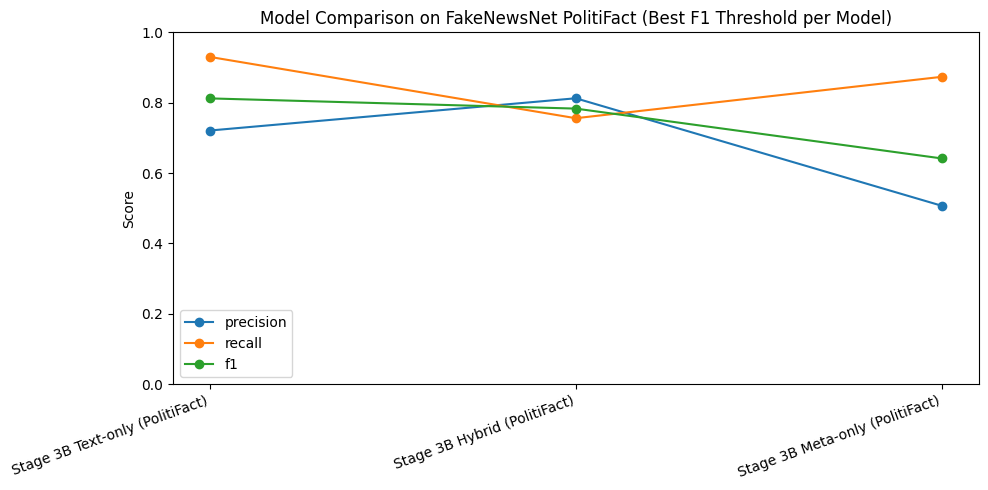

Saved: ../outputs/model_comparison/model_comparison_line.png


In [6]:
# Make a long-format table for plotting
plot_df = summary.melt(id_vars=["model", "threshold"], value_vars=["precision", "recall", "f1"],
                       var_name="metric", value_name="value")

plt.figure(figsize=(10, 5))
for metric in ["precision", "recall", "f1"]:
    subset = plot_df[plot_df["metric"] == metric]
    plt.plot(subset["model"], subset["value"], marker="o", label=metric)

plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Comparison on FakeNewsNet PolitiFact (Best F1 Threshold per Model)")
plt.legend()
plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "model_comparison_line.png")
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)


## Why we only compare Stage 3B models here

Direct model comparison is only meaningful when models are evaluated on the **same dataset** with the **same label definitions** and difficulty.

- **Stages 1–3 (Twitter graph dataset + ISOT)** are used to motivate and validate modeling choices:
  - Stage 1 tests whether early metadata signals alone contain misinformation signal (lower bound).
  - Stage 2 establishes a content-only baseline in a controlled text dataset (upper bound).
  - Stage 3 (Hybrid V0) validates hybrid feature concatenation using text-derived structural features.

However, these earlier datasets differ substantially in:
- unit of observation (tweets vs news articles),
- label generation (folder-derived vs curated/expert-verified),
- and noise/artifact patterns.

Therefore, the controlled comparison is performed exclusively within **FakeNewsNet (PolitiFact)**, where text, metadata, and hybrid models are trained and evaluated under the same conditions.


## Conclusion

On FakeNewsNet (PolitiFact), the **text-only model** provides the strongest standalone signal, while the **metadata-only model** captures weaker but complementary social-context information. The **hybrid model** generally performs best (or ties best), indicating that diffusion/engagement metadata contributes incremental predictive value beyond text alone.

This notebook serves as the final, controlled benchmark comparison for the project.
